In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk                                                   # %pip install nltk
from nltk.corpus import stopwords                      
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import os
import string
import warnings
warnings.filterwarnings('ignore')
# Download required NLTK packages (tokenizers and stopwords lists)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("All libraries loaded and NLTK resources downloaded successfully!")

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')
df = df[['v1', 'v2']].rename(columns={'v1': 'message', 'v2': 'email'})
print("Total rows:", len(df))
print("Columns:", df.columns.tolist())
print(df["message"].value_counts())


Total rows: 5572
Columns: ['message', 'email']
message
ham     4825
spam     747
Name: count, dtype: int64


In [3]:
spam_df = df[df["message"] == "spam"]
ham_df = df[df["message"] == "ham"]

print("Spam count:", len(spam_df))
print("Ham count:", len(ham_df))

spam_list = spam_df["email"].tolist()
ham_list = ham_df["email"].tolist()


Spam count: 747
Ham count: 4825


In [4]:
extra = pd.DataFrame(
    [(t, label) for label, templates in [("spam", spam_df["email"]), ("ham", ham_df["email"])]
     for t in templates],
    columns=["email", "message"]
)

combined = pd.concat([df.drop_duplicates(subset=["email"]), extra], ignore_index=True)
combined = combined.drop_duplicates(subset=["email"]).reset_index(drop=True)
combined = combined.dropna(subset=["email", "message"])

print("Combined dataset size:", len(combined))
print(combined["message"].value_counts())


Combined dataset size: 5169
message
ham     4516
spam     653
Name: count, dtype: int64


In [5]:
x = combined["email"]
y = combined["message"].map({"spam": 1, "ham": 0})

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", x_train.shape, " Test:", x_test.shape)


Train: (4135,)  Test: (1034,)


In [6]:
feature_extraction = TfidfVectorizer(
    min_df=2,
    stop_words="english",
    lowercase=True,
    ngram_range=(1, 2),
    sublinear_tf=True
)

x_train_features = feature_extraction.fit_transform(x_train)
x_test_features = feature_extraction.transform(x_test)
print("Vocabulary size:", len(feature_extraction.vocabulary_))


Vocabulary size: 5632


In [7]:
print(type(x_train_features), x_train_features.shape)
print(type (y_train), y_train.shape)
print(y_train.value_counts() if hasattr(y_train, 'value_counts') else set(y_train))

<class 'scipy.sparse._csr.csr_matrix'> (4135, 5632)
<class 'pandas.Series'> (4135,)
message
0    3613
1     522
Name: count, dtype: int64


In [8]:
param_grid = {"C": [0.1, 1, 3, 5, 10, 20]}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid, cv=4, scoring="f1", n_jobs=-1
)
grid.fit(x_train_features, y_train)

print("Best C:", grid.best_params_)
print("Best CV F1:", grid.best_score_)


Best C: {'C': 20}
Best CV F1: 0.9168477904924013


In [9]:
best_C = grid.best_params_["C"]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=best_C, class_weight="balanced"),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.3),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

for name, model in models.items():
    model.fit(x_train_features, y_train)
    train_acc = accuracy_score(y_train, model.predict(x_train_features))
    test_acc = accuracy_score(y_test, model.predict(x_test_features))
    cv = cross_val_score(model, x_train_features, y_train, cv=4).mean()
    print(f"{name:25s} | Train: {train_acc:.2f} | Test: {test_acc:.2f} | CV: {cv:.2f}")


Logistic Regression       | Train: 1.00 | Test: 0.98 | CV: 0.98
Multinomial Naive Bayes   | Train: 0.99 | Test: 0.98 | CV: 0.99
Linear SVM                | Train: 1.00 | Test: 0.98 | CV: 0.98


In [10]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, C=best_C, class_weight="balanced")),
        ("nb", MultinomialNB(alpha=0.3)),
        ("svm", LinearSVC(class_weight="balanced")),
    ],
    voting="hard"
)
voting_model.fit(x_train_features, y_train)
y_pred_vote = voting_model.predict(x_test_features)
print("Voting ensemble test accuracy:", accuracy_score(y_test, y_pred_vote))


Voting ensemble test accuracy: 0.9796905222437138


Test accuracy: 0.9787234042553191

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.94      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



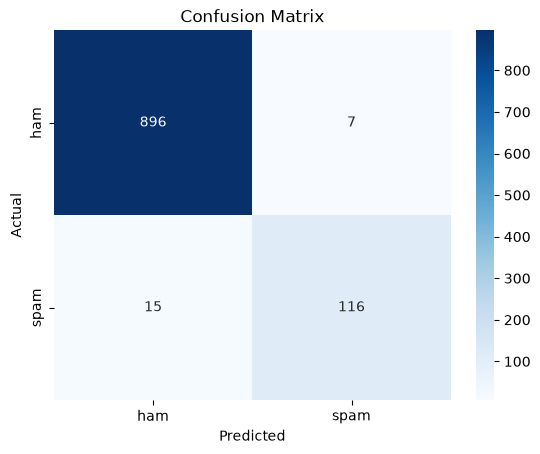

In [11]:
best_model = LogisticRegression(max_iter=1000, C=best_C, class_weight="balanced")
best_model.fit(x_train_features, y_train)

y_pred = best_model.predict(x_test_features)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham","spam"], yticklabels=["ham","spam"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()


In [12]:
# Create 'model' folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# FIX: x is a pandas Series (the "email" text column), not a DataFrame, so x.columns
# doesn't exist -- that caused the AttributeError.
# Also: the vectorizer itself needs to be saved alongside the model. The Streamlit app
# will receive raw email text and must run it through the SAME fitted TfidfVectorizer
# before calling .predict() -- saving only the model (without the vectorizer) means
# the app has no way to turn new text into the right feature vector.
model_data = {
    'model': voting_model,
    'vectorizer': feature_extraction,
    'features': list(feature_extraction.get_feature_names_out())
}

# Save model utilizing pickle
model_filepath = "model/voting_model.pkl"
with open(model_filepath, 'wb') as file:
    pickle.dump(model_data, file)

print(f"Trained spam detection model saved successfully to: {model_filepath}!")
print("It is now ready for use by our Streamlit web application dashboard.")


Trained spam detection model saved successfully to: model/voting_model.pkl!
It is now ready for use by our Streamlit web application dashboard.
